In [31]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from IPython.display import display, Image
from typing import Literal
from random import random

In [32]:
class MultiAttrBoat(TypedDict):
    name: str
    game: Literal['cricket','football']



In [33]:
def playGame(state: MultiAttrBoat):

    print("----Initiated PlayGame Node ----")
    return {"name": f"Hi This is {state['name']}, Wants to Play "}

def cricket(state: MultiAttrBoat):
    print('---Cricket Node has been Called ----')
    return {"name":f"{state['name']} Cricket", state['game']:"cricket"}

def football(state: MultiAttrBoat):
    print('---football Node has been Called ----')
    return {"name":f"{state['name']} Football", state['game']:"football"}


def decisionNode(state: MultiAttrBoat)->Literal["cricket","football"]:

    if random() > 0.5:
        return "cricket"
    else:
        return "football"

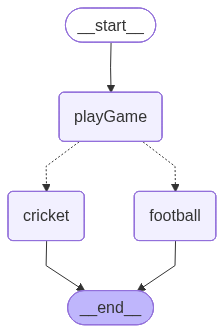

In [34]:
graph = StateGraph(MultiAttrBoat)

graph.add_node("playGame",playGame)
graph.add_node("cricket",cricket)
graph.add_node("football",football)

graph.add_edge(START,"playGame")
graph.add_conditional_edges("playGame", decisionNode)
graph.add_edge("cricket",END)
graph.add_edge("football",END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [56]:
graph_builder.invoke({"name": 123,"game" :""})

----Initiated PlayGame Node ----
---Cricket Node has been Called ----


{'name': 'Hi This is 123, Wants to Play  Cricket', 'game': ''}